# EDA
To ingest 10 years of NVDA historical data into a TimescaleDB instance and perform statistical verification to identify market trends, volatility regimes, and data stationarity.

## A: Imports and Connection

Verify that data can be pulled back out from the database

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import os
from dotenv import load_dotenv

load_dotenv()
DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")
DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("DB_NAME")
db_url = (
    f"postgresql://{DB_USER}:"
    f"{DB_PASSWORD}@"
    f"{DB_HOST}:"
    f"{DB_PORT}/"
    f"{DB_NAME}"
)
engine = create_engine(db_url)

# Fetch data
df = pd.read_sql("SELECT * FROM market_data ORDER BY time ASC", engine)
df['time'] = pd.to_datetime(df['time'])
df.set_index('time', inplace=True)
print("Data loaded successfully.")

# Check how many rows are in the database
print(f"Total rows in DB: {pd.read_sql('SELECT COUNT(*) FROM market_data', engine).iloc[0,0]}")

# Print the columns to ensure they match
print(f"Columns in DF: {df.columns}")

# Print the date range
if not df.empty:
    print(f"Data range: {df.index.min()} to {df.index.max()}")

Data loaded successfully.
Total rows in DB: 2626
Columns in DF: Index(['symbol', 'price_close', 'volume'], dtype='str')
Data range: 2016-01-04 00:00:00+00:00 to 2026-06-12 00:00:00+00:00


## B: Price Trend

Plot the price trend on a 2D graph. Showing the Closing Price against time.

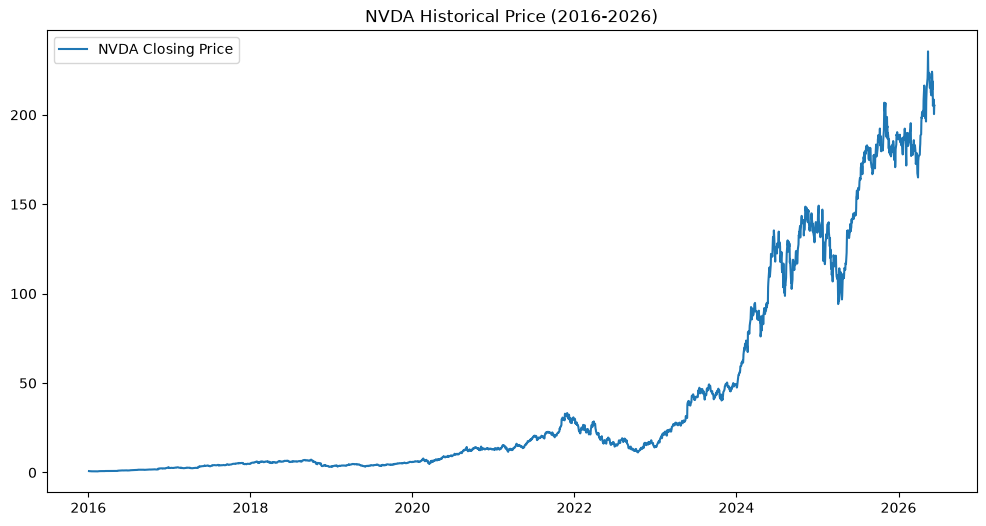

In [2]:
plt.figure(figsize=(12, 6))
plt.plot(df['price_close'], label='NVDA Closing Price')
plt.title('NVDA Historical Price (2016-2026)')
plt.legend()
plt.show()

## C: Feature Engineering

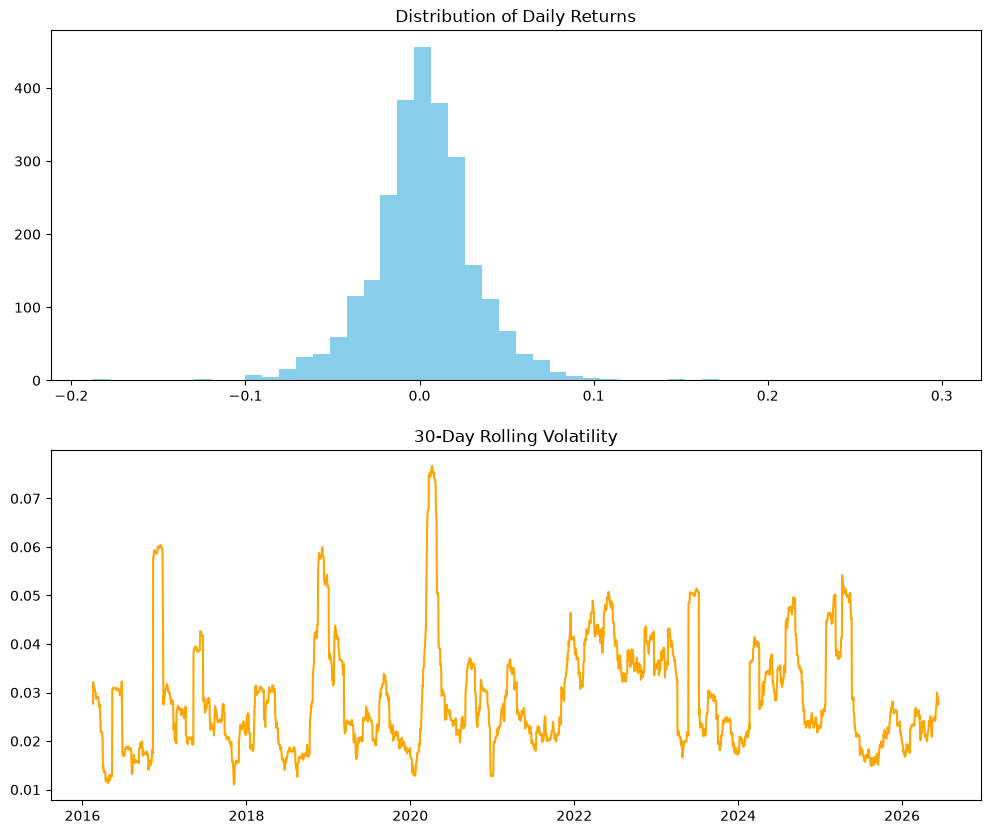

In [3]:
df['returns'] = df['price_close'].pct_change()
df['volatility'] = df['returns'].rolling(window=30).std()

fig, axes = plt.subplots(2, 1, figsize=(12, 10))
axes[0].hist(df['returns'].dropna(), bins=50, color='skyblue')
axes[0].set_title('Distribution of Daily Returns')
axes[1].plot(df['volatility'], color='orange')
axes[1].set_title('30-Day Rolling Volatility')
plt.show()

In [4]:
# Querying a moving average directly from the database
query = """
SELECT time, price_close,
       AVG(price_close) OVER (ORDER BY time ROWS BETWEEN 49 PRECEDING AND CURRENT ROW) as ma_50
FROM market_data
"""
ma_df = pd.read_sql(query, engine)
print(ma_df.tail())

                          time  price_close       ma_50
2621 2026-06-08 00:00:00+00:00   208.639999  203.972014
2622 2026-06-09 00:00:00+00:00   208.190002  204.789315
2623 2026-06-10 00:00:00+00:00   200.419998  205.498160
2624 2026-06-11 00:00:00+00:00   204.869995  206.111621
2625 2026-06-12 00:00:00+00:00   205.190002  206.704513
